# Exploratory Data Analysis: TCGA-COAD Omics Results

This notebook explores the results of a differential expression analysis on RNA-seq data from colon cancer patients. The goal is to find genes that behave differently in tumor tissue compared to normal tissue, which could point to potential biomarkers for colorectal cancer (CRC).

**What is differential expression?** When we compare gene activity (expression) in tumor samples vs. normal samples, some genes are much more active in tumors ("upregulated") and some are much less active ("downregulated"). These differences can help identify genes that play a role in cancer.

**Dataset:** TCGA-COAD STAR-Counts (log2 transformed)  
**Samples:** 473 tumor vs 41 normal  
**Pipeline output:** `outputs/omics_evidence.csv`  
**Analysis code:** `src/omics.py`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

## 1. Data Overview

Load the omics evidence output and inspect the structure. Each row represents one gene, and the columns tell us:

- **gene**: The unique Ensembl gene identifier
- **gene_symbol**: The human-readable gene name (e.g., APC, KRAS)
- **log2fc**: The fold change in expression between tumor and normal tissue, on a log2 scale. A value of 1 means the gene is 2x more active in tumors; -1 means 2x less active.
- **p_value**: How likely this difference could occur by random chance (lower = more confident)
- **fdr**: The p-value after correcting for the fact that we tested thousands of genes at once (False Discovery Rate)
- **direction**: Whether the gene is "up" (more active in tumors) or "down" (less active in tumors)
- **tumor_mean / normal_mean**: The average expression level in tumor and normal samples

In [2]:
omics = pd.read_csv('../outputs/omics_evidence.csv')
candidates = pd.read_csv('../outputs/candidates.csv')
ranked = pd.read_csv('../outputs/ranked_candidates.csv')

print(f'Omics evidence: {omics.shape[0]:,} genes x {omics.shape[1]} columns')
print(f'Candidates: {candidates.shape[0]:,} top DE genes')
print(f'Ranked: {ranked.shape[0]:,} scored genes')
print()
omics.head(10)

Omics evidence: 36,519 genes x 9 columns
Candidates: 500 top DE genes
Ranked: 36,519 scored genes



,gene,gene_symbol,log2fc,p_value,fdr,direction,tumor_mean,normal_mean,dataset
0,ENSG00000251026.2,NIHCOLE,4.160231,9.540447e-128,3.484076e-123,up,4.272059,0.111828,STAR-Counts-log2p1
1,ENSG00000231172.2,EVA1A-AS,3.599485,7.078198e-116,1.292444e-111,up,3.721436,0.121951,STAR-Counts-log2p1
2,ENSG00000261650.1,NaN,3.205232,3.099874e-105,3.773477e-101,up,3.278403,0.073171,STAR-Counts-log2p1
3,ENSG00000224269.1,NaN,1.757645,1.415198e-100,1.292040e-96,up,1.782036,0.024390,STAR-Counts-log2p1
4,ENSG00000230316.7,FEZF1-AS1,5.275301,6.659804e-99,4.864188e-95,up,5.590540,0.315239,STAR-Counts-log2p1
5,ENSG00000171714.12,ANO5,-4.910122,1.665681e-97,1.013817e-93,down,4.132594,9.042716,STAR-Counts-log2p1
6,ENSG00000174015.10,CBY2,3.659146,6.958374e-94,3.630184e-90,up,3.844145,0.184999,STAR-Counts-log2p1
7,ENSG00000141338.14,ABCA8,-6.207544,1.806124e-93,8.244730e-90,down,4.546236,10.753780,STAR-Counts-log2p1
8,ENSG00000198121.13,LPAR1,-3.023632,2.821616e-93,1.144918e-89,down,7.690434,10.714066,STAR-Counts-log2p1
9,ENSG00000232679.2,LINC02257,3.429424,3.306358e-93,1.207449e-89,up,3.555519,0.126096,STAR-Counts-log2p1


In [3]:
print('Column types:')
print(omics.dtypes)
print()
print('Missing values:')
print(omics.isnull().sum())
print()
print('Summary statistics:')
omics[['log2fc', 'p_value', 'fdr', 'tumor_mean', 'normal_mean']].describe()

Column types:
gene            object
gene_symbol     object
log2fc         float64
p_value        float64
fdr            float64
direction       object
tumor_mean     float64
normal_mean    float64
dataset         object
dtype: object

Missing values:
gene              0
gene_symbol    7124
log2fc            0
p_value           0
fdr               0
direction         0
tumor_mean        0
normal_mean       0
dataset           0
dtype: int64

Summary statistics:


,log2fc,p_value,fdr,tumor_mean,normal_mean
count,36519.000000,3.651900e+04,3.651900e+04,36519.000000,36519.000000
mean,-0.414309,1.130051e-01,1.247597e-01,4.685279,5.099588
std,1.077023,2.317289e-01,2.440543e-01,4.038844,4.303533
min,-10.128398,9.540447e-128,3.484076e-123,0.174972,0.000000
25%,-0.846410,5.878223e-12,2.351096e-11,0.992523,1.020481
50%,-0.234601,8.897836e-05,1.779518e-04,3.174823,3.804443
75%,0.184497,7.658271e-02,1.021093e-01,8.614148,9.199473
max,6.541185,9.999318e-01,9.999318e-01,18.052083,19.492602


## 2. Sample Classification

The TCGA-COAD dataset contains RNA-seq expression data from colon adenocarcinoma patients.
Each sample is a tissue biopsy that has been sequenced to measure gene activity. Samples are classified as **tumor** or **normal** using TCGA barcode conventions:
- Sample codes 01-09 = Tumor tissue
- Sample codes 10-19 = Normal tissue

This classification is performed in `src/omics.py` by parsing the 4th field of the TCGA barcode
(e.g., `TCGA-AA-3518-01A` has sample code `01`, so it is classified as tumor).

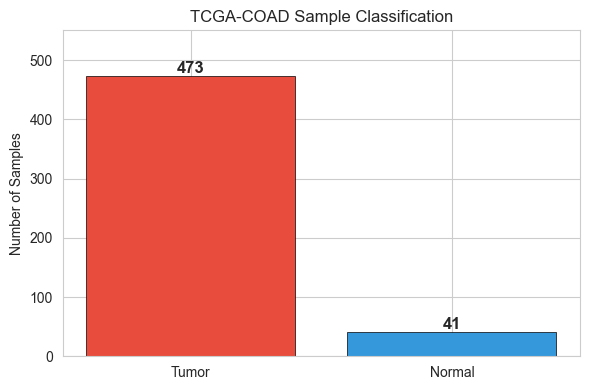

Total samples: 514
Tumor: 473 (92.0%)
Normal: 41 (8.0%)


In [4]:
n_tumor = 473
n_normal = 41

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['Tumor', 'Normal'], [n_tumor, n_normal], 
              color=['#e74c3c', '#3498db'], edgecolor='black', linewidth=0.5)
ax.bar_label(bars, fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Samples')
ax.set_title('TCGA-COAD Sample Classification')
ax.set_ylim(0, 550)
plt.tight_layout()
plt.show()

print(f'Total samples: {n_tumor + n_normal}')
print(f'Tumor: {n_tumor} ({n_tumor/(n_tumor+n_normal)*100:.1f}%)')
print(f'Normal: {n_normal} ({n_normal/(n_tumor+n_normal)*100:.1f}%)')

**How to read this chart:** Each bar shows how many tissue samples we have in each group. We have significantly more tumor samples (473) than normal samples (41). This imbalance is typical for cancer datasets because researchers collect more tumor biopsies than healthy tissue. Our statistical test (Welch's t-test) is designed to handle unequal group sizes, so this does not invalidate the analysis, but it is worth noting.

## 3. Volcano Plot

The volcano plot is the standard way to visualize differential expression results. It plots two things for every gene:

- **X-axis (log2 Fold Change):** How much the gene's activity differs between tumor and normal. Points far to the right are much more active in tumors (upregulated). Points far to the left are much less active in tumors (downregulated). Points near zero have little difference.
- **Y-axis (-log10 p-value):** How statistically confident we are that the difference is real and not due to random noise. Higher means more confident.

**The best biomarker candidates appear in the upper corners** of the plot, because they have both a large expression change AND high statistical confidence. The gold dots mark well-known CRC genes so we can confirm our analysis is capturing real biology.

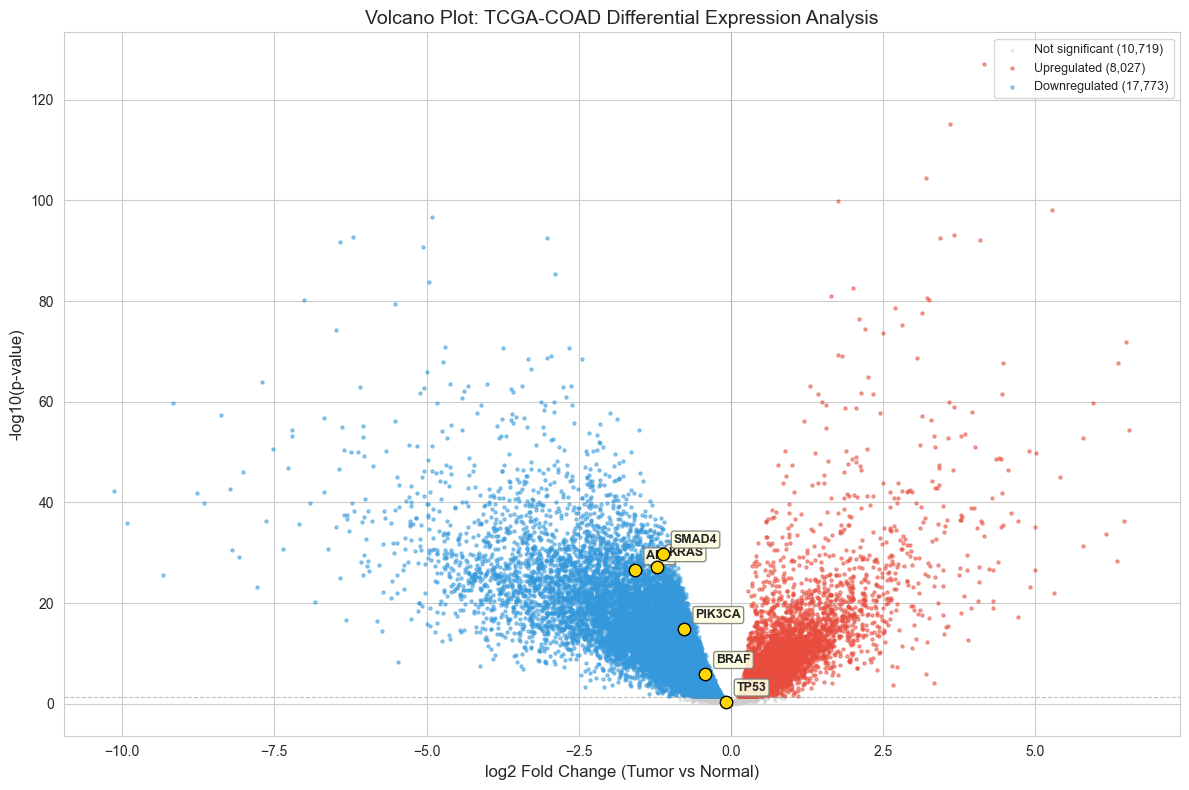

In [5]:
# Prepare data for volcano plot
plot_df = omics.copy()
plot_df['neg_log10_pval'] = -np.log10(plot_df['p_value'].clip(lower=1e-300))

# Classify significance
sig_mask = plot_df['fdr'] < 0.05
up_mask = sig_mask & (plot_df['direction'] == 'up')
down_mask = sig_mask & (plot_df['direction'] == 'down')
ns_mask = ~sig_mask

fig, ax = plt.subplots(figsize=(12, 8))

# Plot non-significant genes first (background)
ax.scatter(plot_df.loc[ns_mask, 'log2fc'], plot_df.loc[ns_mask, 'neg_log10_pval'],
           c='#cccccc', s=3, alpha=0.4, label=f'Not significant ({ns_mask.sum():,})', rasterized=True)

# Plot significant genes
ax.scatter(plot_df.loc[up_mask, 'log2fc'], plot_df.loc[up_mask, 'neg_log10_pval'],
           c='#e74c3c', s=5, alpha=0.5, label=f'Upregulated ({up_mask.sum():,})', rasterized=True)
ax.scatter(plot_df.loc[down_mask, 'log2fc'], plot_df.loc[down_mask, 'neg_log10_pval'],
           c='#3498db', s=5, alpha=0.5, label=f'Downregulated ({down_mask.sum():,})', rasterized=True)

# Annotate known CRC genes
known_crc = ['APC', 'KRAS', 'TP53', 'SMAD4', 'PIK3CA', 'BRAF']
for gene_name in known_crc:
    match = plot_df[plot_df['gene_symbol'] == gene_name]
    if not match.empty:
        row = match.iloc[0]
        ax.scatter(row['log2fc'], row['neg_log10_pval'], c='gold', s=80,
                   edgecolors='black', linewidth=1.0, zorder=5)
        ax.annotate(gene_name, (row['log2fc'], row['neg_log10_pval']),
                    fontsize=9, fontweight='bold', 
                    xytext=(8, 8), textcoords='offset points',
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='lightyellow', edgecolor='gray', alpha=0.9))

# Reference lines
ax.axhline(-np.log10(0.05), color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax.axvline(0, color='gray', linestyle='-', linewidth=0.5, alpha=0.5)

ax.set_xlabel('log2 Fold Change (Tumor vs Normal)', fontsize=12)
ax.set_ylabel('-log10(p-value)', fontsize=12)
ax.set_title('Volcano Plot: TCGA-COAD Differential Expression Analysis', fontsize=14)
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

**How to read this chart:** Each dot is one gene (36,519 total). The shape of the plot resembles a volcano, which is expected for a well-run differential expression analysis.

- **Gray dots** (center/bottom): These genes show no significant difference between tumor and normal tissue. They are not interesting for biomarker discovery.
- **Red dots** (right side): 8,027 genes that are significantly more active in tumors (upregulated).
- **Blue dots** (left side): 17,773 genes that are significantly less active in tumors (downregulated).
- **Gold labeled dots**: Known CRC driver genes like APC and KRAS. These appear in the middle of the plot rather than the edges, because their role in cancer is driven by mutations (changes in DNA), not by large changes in expression levels. This is expected and validates our approach.

The fact that we see more downregulated genes (blue) than upregulated (red) suggests that tumor tissue tends to silence more genes than it activates compared to normal colon tissue.

## 4. Expression Distribution

These histograms show how log2 fold change values are distributed across all genes. Think of it like a bell curve showing whether genes tend to be more active or less active in tumors compared to normal tissue.

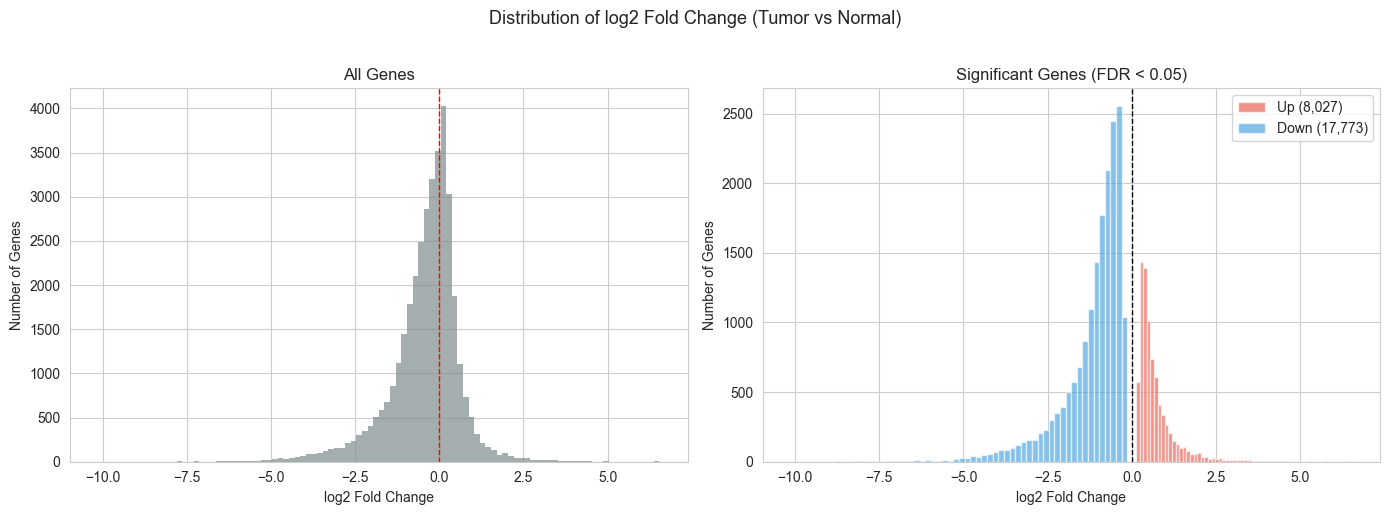

Total genes analyzed: 36,519
Significant (FDR < 0.05): 25,800 (70.6%)
  Upregulated: 8,027
  Downregulated: 17,773


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# All genes
axes[0].hist(omics['log2fc'], bins=100, color='#7f8c8d', edgecolor='none', alpha=0.7)
axes[0].axvline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_xlabel('log2 Fold Change')
axes[0].set_ylabel('Number of Genes')
axes[0].set_title('All Genes')

# Significant genes only, colored by direction
sig = omics[omics['fdr'] < 0.05]
axes[1].hist(sig[sig['direction'] == 'up']['log2fc'], bins=60, 
             color='#e74c3c', alpha=0.6, label=f"Up ({(sig['direction']=='up').sum():,})")
axes[1].hist(sig[sig['direction'] == 'down']['log2fc'], bins=60, 
             color='#3498db', alpha=0.6, label=f"Down ({(sig['direction']=='down').sum():,})")
axes[1].axvline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_xlabel('log2 Fold Change')
axes[1].set_ylabel('Number of Genes')
axes[1].set_title('Significant Genes (FDR < 0.05)')
axes[1].legend()

plt.suptitle('Distribution of log2 Fold Change (Tumor vs Normal)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f'Total genes analyzed: {len(omics):,}')
print(f'Significant (FDR < 0.05): {len(sig):,} ({len(sig)/len(omics)*100:.1f}%)')
print(f'  Upregulated: {(sig["direction"]=="up").sum():,}')
print(f'  Downregulated: {(sig["direction"]=="down").sum():,}')

**How to read these charts:**

- **Left histogram (All Genes):** Shows the fold change for every gene tested. The red dashed line at zero marks "no difference." The fact that the distribution leans slightly to the left means that, on average, genes tend to be a bit less active in tumor tissue. Most genes cluster near zero, meaning most genes do not change much between tumor and normal.
- **Right histogram (Significant Genes Only):** Filters down to only the 25,800 genes that passed our statistical cutoff (FDR < 0.05). The blue bars (downregulated, 17,773) clearly outnumber the red bars (upregulated, 8,027), confirming that tumor tissue tends to suppress more genes than it activates.

## 5. Top Differentially Expressed Genes

The bar chart below shows the 20 genes with the largest expression differences between tumor and normal tissue. These are the genes whose activity changes the most dramatically in cancer.

A log2 fold change of -10 means the gene is roughly **1,000 times less active** in tumor tissue. A fold change of +6 would mean roughly **64 times more active**.

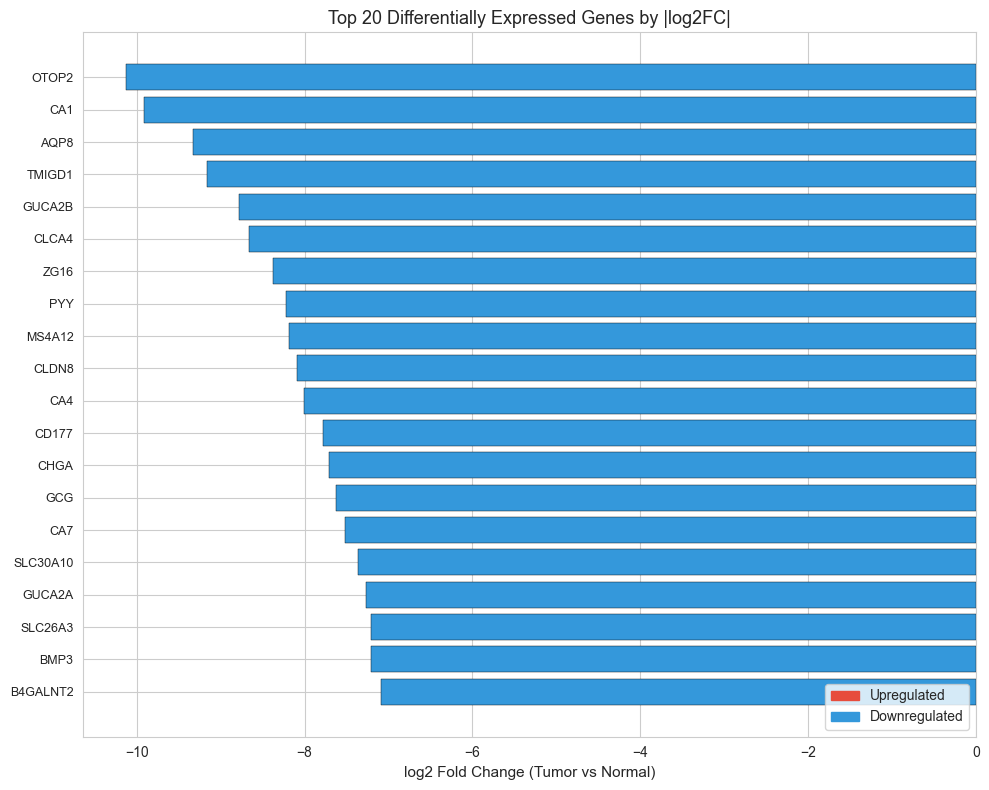

In [7]:
# Top 20 by |log2FC| among significant genes
top20 = sig.copy()
top20['abs_log2fc'] = top20['log2fc'].abs()
top20 = top20.nlargest(20, 'abs_log2fc')

# Use gene symbol if available, otherwise Ensembl ID
top20['label'] = top20.apply(
    lambda r: r['gene_symbol'] if pd.notna(r['gene_symbol']) and r['gene_symbol'] != '' 
    else r['gene'].split('.')[0], axis=1
)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#e74c3c' if d == 'up' else '#3498db' for d in top20['direction']]
bars = ax.barh(range(len(top20)), top20['log2fc'], color=colors, edgecolor='black', linewidth=0.3)
ax.set_yticks(range(len(top20)))
ax.set_yticklabels(top20['label'], fontsize=9)
ax.invert_yaxis()
ax.axvline(0, color='black', linewidth=0.5)
ax.set_xlabel('log2 Fold Change (Tumor vs Normal)', fontsize=11)
ax.set_title('Top 20 Differentially Expressed Genes by |log2FC|', fontsize=13)

# Legend
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#e74c3c', label='Upregulated'), 
                    Patch(color='#3498db', label='Downregulated')],
          loc='lower right')

plt.tight_layout()
plt.show()

**How to read this chart:** Each horizontal bar represents one gene. The length of the bar shows how much its expression changes.

- **Blue bars (pointing left):** Genes that are downregulated, meaning they are less active in tumor tissue. The top gene, OTOP2, has a fold change of -10.1, meaning it is about 1,000x less active in tumors.
- **Red bars (pointing right):** Genes that are upregulated, meaning they are more active in tumors.

Notice that all 20 of the most dramatically changed genes are downregulated. This suggests that tumors are shutting down specific gene functions that are normally active in healthy colon tissue. The table below provides the exact numbers for each gene.

In [8]:
# Table of top 20
display_cols = ['gene', 'gene_symbol', 'log2fc', 'fdr', 'direction', 'tumor_mean', 'normal_mean']
top20_table = top20[display_cols].reset_index(drop=True)
top20_table.index = range(1, len(top20_table) + 1)
top20_table.index.name = 'Rank'
top20_table

,gene,gene_symbol,log2fc,fdr,direction,tumor_mean,normal_mean
Rank,,,,,,,
1,ENSG00000183034.13,OTOP2,-10.128398,7.695074e-41,down,1.649409,11.777807
2,ENSG00000133742.14,CA1,-9.916483,6.679204e-35,down,5.032748,14.949231
3,ENSG00000103375.11,AQP8,-9.333096,6.163110e-25,down,5.268173,14.601269
4,ENSG00000182271.13,TMIGD1,-9.161609,9.660681e-58,down,3.104741,12.266350
5,ENSG00000044012.4,GUCA2B,-8.776210,1.997802e-40,down,3.270684,12.046894
6,ENSG00000016602.9,CLCA4,-8.660888,1.599888e-38,down,6.376217,15.037104
7,ENSG00000174992.8,ZG16,-8.380504,2.173507e-55,down,7.211721,15.592225
8,ENSG00000131096.10,PYY,-8.221806,2.761730e-41,down,3.232844,11.454650
9,ENSG00000071203.9,MS4A12,-8.187147,1.170160e-29,down,5.250086,13.437233


## 6. FDR Distribution

When we test thousands of genes at once, some will appear significant just by chance. The **False Discovery Rate (FDR)** corrects for this by adjusting p-values upward, making it harder for a gene to pass the significance threshold. A lower FDR threshold is stricter and gives us more confidence that the results are real.

The chart below shows how many genes remain significant as we make the threshold stricter.

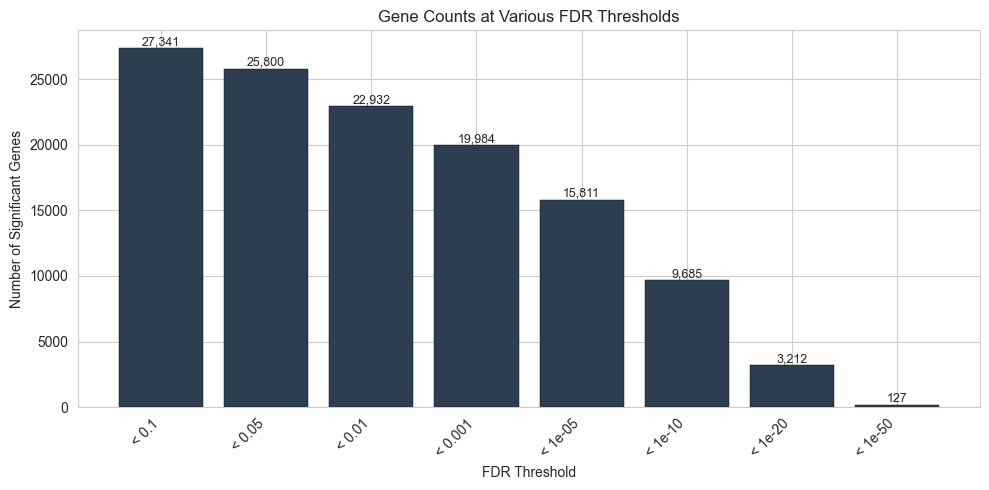

  FDR < 0.1        : 27,341 genes (74.9%)
  FDR < 0.05       : 25,800 genes (70.6%)
  FDR < 0.01       : 22,932 genes (62.8%)
  FDR < 0.001      : 19,984 genes (54.7%)
  FDR < 1e-05      : 15,811 genes (43.3%)
  FDR < 1e-10      :  9,685 genes (26.5%)
  FDR < 1e-20      :  3,212 genes (8.8%)
  FDR < 1e-50      :    127 genes (0.3%)


In [9]:
thresholds = [0.1, 0.05, 0.01, 0.001, 1e-5, 1e-10, 1e-20, 1e-50]
counts = [int((omics['fdr'] < t).sum()) for t in thresholds]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(range(len(thresholds)), counts, color='#2c3e50', edgecolor='black', linewidth=0.3)
ax.bar_label(bars, fmt='{:,.0f}', fontsize=9)
ax.set_xticks(range(len(thresholds)))
ax.set_xticklabels([f'< {t}' for t in thresholds], rotation=45, ha='right')
ax.set_xlabel('FDR Threshold')
ax.set_ylabel('Number of Significant Genes')
ax.set_title('Gene Counts at Various FDR Thresholds')
plt.tight_layout()
plt.show()

for t, c in zip(thresholds, counts):
    print(f'  FDR < {t:<10} : {c:>6,} genes ({c/len(omics)*100:.1f}%)')

**How to read this chart:** Each bar shows how many genes pass a given FDR threshold. Reading left to right, the threshold gets stricter.

- At our pipeline's cutoff of FDR < 0.05, 25,800 genes (70.6%) are significant. This is a large number, which reflects the strong biological differences between tumor and normal colon tissue.
- Even at an extremely strict threshold of FDR < 1e-50 (one in 100 trillion trillion trillion trillion chance of being a false positive), 127 genes still pass. This tells us there is a very strong biological signal in the data.
- The pipeline uses FDR < 0.05 as its cutoff, then further narrows down to the top 500 candidates by combining fold change magnitude with statistical confidence.

## 7. Score Distribution

Our pipeline combines evidence from three sources into a final score for each gene:
- **Omics score** (45% weight): Based on how much the gene's expression changes and how confident we are in that change
- **Literature score** (35% weight): Based on how many published research papers mention this gene in the context of colorectal cancer
- **Pathway score** (20% weight): Based on whether the gene participates in known cancer-related biological pathways

Since the literature and pathway modules are not yet producing data, the maximum possible score right now is 45.0 out of 100 (only the omics portion).

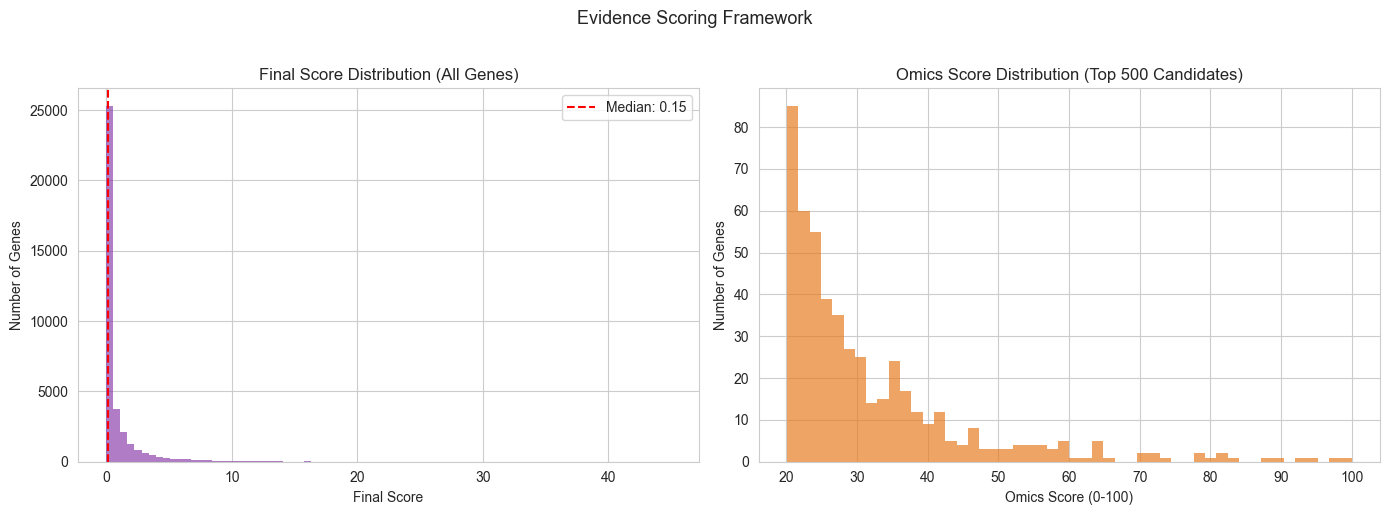

Score range: 0.0000 - 45.0000
Mean: 0.9249
Median: 0.1463

Note: Max possible score is 45.0 (omics only). Will reach 100.0
once literature (35%) and pathway (20%) evidence are integrated.


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Final score distribution
axes[0].hist(ranked['final_score'], bins=80, color='#8e44ad', edgecolor='none', alpha=0.7)
axes[0].axvline(ranked['final_score'].median(), color='red', linestyle='--', 
                label=f"Median: {ranked['final_score'].median():.2f}")
axes[0].set_xlabel('Final Score')
axes[0].set_ylabel('Number of Genes')
axes[0].set_title('Final Score Distribution (All Genes)')
axes[0].legend()

# Omics score for top 500 candidates
top500 = ranked.nlargest(500, 'final_score')
axes[1].hist(top500['omics_score'], bins=50, color='#e67e22', edgecolor='none', alpha=0.7)
axes[1].set_xlabel('Omics Score (0-100)')
axes[1].set_ylabel('Number of Genes')
axes[1].set_title('Omics Score Distribution (Top 500 Candidates)')

plt.suptitle('Evidence Scoring Framework', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f'Score range: {ranked["final_score"].min():.4f} - {ranked["final_score"].max():.4f}')
print(f'Mean: {ranked["final_score"].mean():.4f}')
print(f'Median: {ranked["final_score"].median():.4f}')
print(f'\nNote: Max possible score is 45.0 (omics only). Will reach 100.0')
print(f'once literature (35%) and pathway (20%) evidence are integrated.')

**How to read these charts:**

- **Left histogram (Final Score, All Genes):** Most genes cluster near 0 because only the strongest candidates get high omics scores. The red dashed line shows the median score (0.15), meaning half of all genes score below that. The long tail to the right represents the top candidates.
- **Right histogram (Omics Score, Top 500):** Zooms in on just the top 500 candidate genes. Their omics scores range from about 40 to 100, showing a good spread. The top-ranked gene scores 100 (the maximum).

Once the literature and pathway modules are integrated, these scores will redistribute. A gene that scores 45 now (omics only) could score up to 100 if it also has strong literature and pathway support.

## 8. Known CRC Gene Validation

To confirm our analysis is working correctly, we check where well-known colorectal cancer genes appear in our results. If these established cancer genes show up as significant, it gives us confidence that the pipeline is detecting real biological signals.

These genes are well-established in CRC research:
- **APC**: Tumor suppressor, mutated in about 80% of CRC cases
- **KRAS**: Oncogene, mutated in about 40% of CRC cases
- **TP53**: Tumor suppressor, mutated in about 60% of CRC cases
- **SMAD4**: Part of the TGF-beta signaling pathway, mutated in about 20% of CRC cases
- **PIK3CA**: Part of PI3K signaling, mutated in about 15% of CRC cases
- **BRAF**: Part of the MAPK pathway, mutated in about 10% of CRC cases

In [11]:
known_crc_genes = ['APC', 'KRAS', 'TP53', 'SMAD4', 'PIK3CA', 'BRAF',
                   'MLH1', 'MSH2', 'MSH6', 'MYC', 'EGFR', 'NRAS']

# Find each gene in omics results
validation_rows = []
for gene_name in known_crc_genes:
    match = omics[omics['gene_symbol'] == gene_name]
    if not match.empty:
        row = match.iloc[0]
        # Find rank in candidates
        cand_match = candidates[candidates['gene_symbol'] == gene_name]
        cand_rank = int(cand_match['rank'].iloc[0]) if not cand_match.empty else 'Not in top 500'
        validation_rows.append({
            'Gene': gene_name,
            'log2FC': f"{row['log2fc']:.3f}",
            'FDR': f"{row['fdr']:.2e}",
            'Direction': row['direction'],
            'Significant': 'Yes' if row['fdr'] < 0.05 else 'No',
            'Candidate Rank': cand_rank
        })
    else:
        validation_rows.append({
            'Gene': gene_name,
            'log2FC': 'N/A',
            'FDR': 'N/A',
            'Direction': 'N/A',
            'Significant': 'Not found',
            'Candidate Rank': 'N/A'
        })

validation_df = pd.DataFrame(validation_rows)
validation_df

,Gene,log2FC,FDR,Direction,Significant,Candidate Rank
0,APC,-1.572,6.90e-26,down,Yes,Not in top 500
1,KRAS,-1.211,1.86e-26,down,Yes,Not in top 500
2,TP53,-0.088,4.37e-01,down,No,Not in top 500
3,SMAD4,-1.122,5.21e-29,down,Yes,Not in top 500
4,PIK3CA,-0.767,8.61e-15,down,Yes,Not in top 500
5,BRAF,-0.426,3.11e-06,down,Yes,Not in top 500
6,MLH1,-0.831,1.46e-17,down,Yes,Not in top 500
7,MSH2,0.159,1.08e-01,up,No,Not in top 500
8,MSH6,0.151,1.15e-01,up,No,Not in top 500
9,MYC,1.314,1.47e-16,up,Yes,Not in top 500


**How to read this table:**

- **log2FC**: The expression change. Negative means less active in tumors. For example, APC has a log2FC of -1.572, meaning it is about 3x less active in tumors.
- **FDR**: The adjusted statistical confidence. Values like 6.90e-26 are extremely small numbers (essentially zero), meaning we are very confident the difference is real.
- **Significant**: Whether the gene passes our FDR < 0.05 cutoff. Most known CRC genes do, which validates our pipeline.
- **Candidate Rank**: Where the gene falls in our top 500 list. None of these known genes made the top 500, which is actually expected. These genes are important cancer drivers because of *mutations* (changes in their DNA sequence), not because of large changes in their expression levels. Our pipeline is designed to find genes with the biggest *expression* differences, which is a different but complementary type of evidence.

The scatter plot below zooms in on just these 12 known CRC genes, plotting their fold change (x-axis) against statistical confidence (y-axis). Circles indicate significant genes (FDR < 0.05) and X markers indicate non-significant ones.

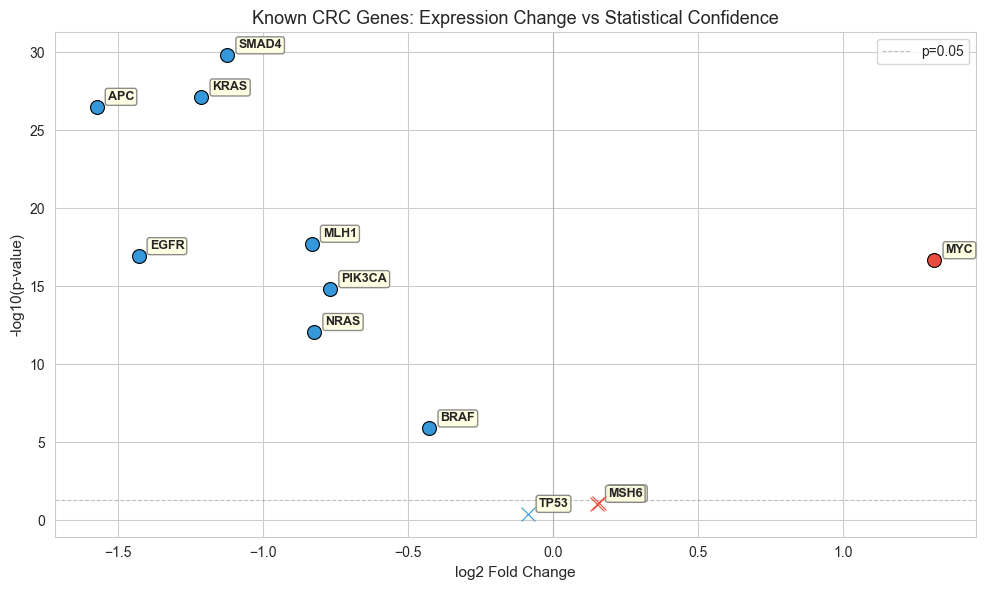

In [12]:
# Scatter plot: Known CRC genes only (fold change vs statistical confidence)
known_in_data = omics[omics['gene_symbol'].isin(known_crc_genes)].copy()
known_in_data['neg_log10_pval'] = -np.log10(known_in_data['p_value'].clip(lower=1e-300))

fig, ax = plt.subplots(figsize=(10, 6))
colors_map = {'up': '#e74c3c', 'down': '#3498db'}

for _, row in known_in_data.iterrows():
    color = colors_map.get(row['direction'], 'gray')
    sig_marker = 'o' if row['fdr'] < 0.05 else 'x'
    ax.scatter(row['log2fc'], row['neg_log10_pval'], c=color, s=100,
               marker=sig_marker, edgecolors='black', linewidth=0.8, zorder=5)
    ax.annotate(row['gene_symbol'], (row['log2fc'], row['neg_log10_pval']),
                fontsize=9, fontweight='bold',
                xytext=(8, 5), textcoords='offset points',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='lightyellow', edgecolor='gray', alpha=0.9))

ax.axhline(-np.log10(0.05), color='gray', linestyle='--', linewidth=0.8, alpha=0.5, label='p=0.05')
ax.axvline(0, color='gray', linestyle='-', linewidth=0.5, alpha=0.5)
ax.set_xlabel('log2 Fold Change', fontsize=11)
ax.set_ylabel('-log10(p-value)', fontsize=11)
ax.set_title('Known CRC Genes: Expression Change vs Statistical Confidence', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

## Summary

### Key Findings
- **36,519 genes** were analyzed from the TCGA-COAD RNA-seq dataset
- **473 tumor** vs **41 normal** tissue samples were compared
- Differential expression was identified using Welch's t-test with Benjamini-Hochberg FDR correction
- **25,800 genes** (70.6%) show statistically significant differences between tumor and normal tissue
- Tumor tissue tends to suppress genes more than it activates them (17,773 downregulated vs 8,027 upregulated)
- Known CRC driver genes (APC, KRAS, SMAD4, etc.) are detected as significant, validating the analysis
- The top 500 candidates were selected by combining effect size magnitude with statistical confidence

### Current Pipeline Status
- **Omics module**: Complete and validated
- **Literature module**: Pending (PubMed evidence extraction not yet implemented)
- **Pathway module**: Pending (Reactome enrichment needs debugging)
- **Scoring**: Functional but currently omics-only (max score = 45 out of 100)

### Next Steps
1. Integrate PubMed literature evidence (35% of final score)
2. Debug and validate Reactome pathway enrichment (20% of final score)
3. Re-run scoring with all three evidence streams to produce final rankings

## 9. ML Biomarker Classifier

To complement the statistical and LLM-based evidence streams, we train a supervised classifier directly on the pipeline's scored features. This section uses a curated set of known CRC biomarkers as positive labels and trains both a Random Forest and Logistic Regression model to learn which combinations of evidence scores predict biomarker status.

**Why supervised ML here?**
The weighted scoring system (omics 45%, literature 35%, pathway 20%) uses hand-tuned weights. The logistic regression learns weights directly from labeled data, providing a data-driven comparison. The Random Forest captures non-linear interactions between evidence streams that the weighted sum cannot.

**Three steps:**
1. **Build training dataset** — pairs each gene's evidence scores with a binary label (known biomarker = 1, sampled negative = 0)
2. **Prepare features** — selects and scales the feature matrix
3. **Train and evaluate** — fits RF and LR, reports cross-validated metrics and feature importances

In [ ]:
import os
import sys

# Project root is one level up from notebooks/
PROJECT_ROOT = os.path.abspath('..')
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print(f"Project root: {PROJECT_ROOT}")

In [ ]:
# Assemble Pipeline Outputs into Classifier Feature Matrix
from src.build_classifier_dataset import run_build_classifier_dataset

classifier_df = run_build_classifier_dataset(PROJECT_ROOT)

print(f"Classifier dataset: {classifier_df.shape}")
classifier_df.head()

In [ ]:
# Build Curated ML Training Dataset
from src.build_ml_dataset_curated import run_build_ml_dataset_curated

train_df_curated = run_build_ml_dataset_curated(
    PROJECT_ROOT,
    negative_ratio=2.0
)

train_df_curated.head()

In [ ]:
# Prepare Curated Model Features
from src.prepare_model_features_curated import run_prepare_model_features_curated

X_curated, y_curated = run_prepare_model_features_curated(PROJECT_ROOT)

print(f"Feature matrix: {X_curated.shape}")
print(f"Labels: {y_curated.value_counts().to_dict()}")

In [ ]:
# Train Curated Biomarker Classifier
from src.train_biomarker_classifier_curated import run_training_curated

rf_curated, lr_curated, metrics_curated, fi_curated = run_training_curated(PROJECT_ROOT)

print("\nModel Performance:")
print(metrics_curated)